# Heart Disease Prediction — Deep Learning Project 
**Name:** IFRAH JAMIL  
**Reg No:** FA23-BBD-059  
**Section:** BDA-6B  

---
**Framework:** TensorFlow / Keras  
**Model:** Artificial Neural Network (ANN)  
**Task:** Binary Classification — Heart Disease Prediction


## Step 1 — Install & Import Libraries

In [21]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import warnings
warnings.filterwarnings('ignore')

# Scikit-learn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# TensorFlow / Keras
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

print(" All libraries imported successfully!")
print(f"TensorFlow version : {tf.__version__}")
print(f"Keras version      : {keras.__version__}")


 All libraries imported successfully!
TensorFlow version : 2.21.0
Keras version      : 3.12.2


## Step 2 — Load Dataset

In [22]:

df = pd.read_csv(r"C:\Users\LENOVO\Downloads\heart_disease.csv")

print("Dataset shape:", df.shape)
print("\nFirst 5 rows:")
df.head()


Dataset shape: (10000, 21)

First 5 rows:


,Age,Gender,Blood Pressure,Cholesterol Level,Exercise Habits,Smoking,Family Heart Disease,Diabetes,BMI,High Blood Pressure,...,High LDL Cholesterol,Alcohol Consumption,Stress Level,Sleep Hours,Sugar Consumption,Triglyceride Level,Fasting Blood Sugar,CRP Level,Homocysteine Level,Heart Disease Status
0,56.0,Male,153.0,155.0,High,Yes,Yes,No,24.991591,Yes,...,No,High,Medium,7.633228,Medium,342.0,NaN,12.969246,12.387250,No
1,69.0,Female,146.0,286.0,High,No,Yes,Yes,25.221799,No,...,No,Medium,High,8.744034,Medium,133.0,157.0,9.355389,19.298875,No
2,46.0,Male,126.0,216.0,Low,No,No,No,29.855447,No,...,Yes,Low,Low,4.440440,Low,393.0,92.0,12.709873,11.230926,No
3,32.0,Female,122.0,293.0,High,Yes,Yes,No,24.130477,Yes,...,Yes,Low,High,5.249405,High,293.0,94.0,12.509046,5.961958,No
4,60.0,Male,166.0,242.0,Low,Yes,Yes,Yes,20.486289,Yes,...,No,Low,High,7.030971,High,263.0,154.0,10.381259,8.153887,No


## Step 3 — Exploratory Data Analysis (EDA)

In [23]:
print("=== Dataset Info ===")
df.info()
print("\n=== Statistical Summary ===")
df.describe()


=== Dataset Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Age                   9971 non-null   float64
 1   Gender                9981 non-null   object 
 2   Blood Pressure        9981 non-null   float64
 3   Cholesterol Level     9970 non-null   float64
 4   Exercise Habits       9975 non-null   object 
 5   Smoking               9975 non-null   object 
 6   Family Heart Disease  9979 non-null   object 
 7   Diabetes              9970 non-null   object 
 8   BMI                   9978 non-null   float64
 9   High Blood Pressure   9974 non-null   object 
 10  Low HDL Cholesterol   9975 non-null   object 
 11  High LDL Cholesterol  9974 non-null   object 
 12  Alcohol Consumption   7414 non-null   object 
 13  Stress Level          9978 non-null   object 
 14  Sleep Hours           9975 non-null   float64
 15 

,Age,Blood Pressure,Cholesterol Level,BMI,Sleep Hours,Triglyceride Level,Fasting Blood Sugar,CRP Level,Homocysteine Level
count,9971.000000,9981.000000,9970.000000,9978.000000,9975.000000,9974.000000,9978.000000,9974.000000,9980.000000
mean,49.296259,149.757740,225.425577,29.077269,6.991329,250.734409,120.142213,7.472201,12.456271
std,18.193970,17.572969,43.575809,6.307098,1.753195,87.067226,23.584011,4.340248,4.323426
min,18.000000,120.000000,150.000000,18.002837,4.000605,100.000000,80.000000,0.003647,5.000236
25%,34.000000,134.000000,187.000000,23.658075,5.449866,176.000000,99.000000,3.674126,8.723334
50%,49.000000,150.000000,226.000000,29.079492,7.003252,250.000000,120.000000,7.472164,12.409395
75%,65.000000,165.000000,263.000000,34.520015,8.531577,326.000000,141.000000,11.255592,16.140564
max,80.000000,180.000000,300.000000,39.996954,9.999952,400.000000,160.000000,14.997087,19.999037


In [24]:
print("Missing Values")
print(df.isnull().sum())
print(f"\nTotal missing: {df.isnull().sum().sum()}")


Missing Values
Age                       29
Gender                    19
Blood Pressure            19
Cholesterol Level         30
Exercise Habits           25
Smoking                   25
Family Heart Disease      21
Diabetes                  30
BMI                       22
High Blood Pressure       26
Low HDL Cholesterol       25
High LDL Cholesterol      26
Alcohol Consumption     2586
Stress Level              22
Sleep Hours               25
Sugar Consumption         30
Triglyceride Level        26
Fasting Blood Sugar       22
CRP Level                 26
Homocysteine Level        20
Heart Disease Status       0
dtype: int64

Total missing: 3054


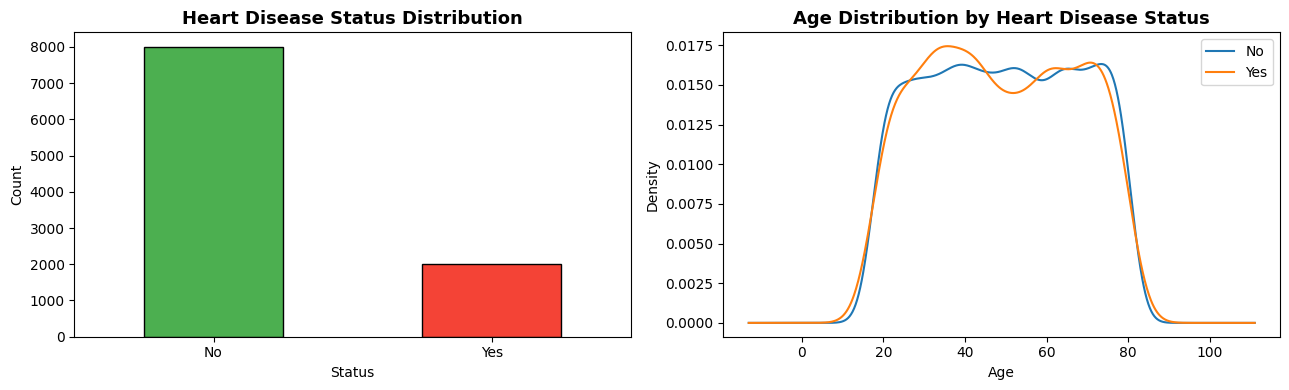

In [25]:
# Target distribution and Age distribution
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

df['Heart Disease Status'].value_counts().plot(
    kind='bar', ax=axes[0], color=['#4CAF50','#F44336'], edgecolor='black'
)
axes[0].set_title('Heart Disease Status Distribution', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Status'); axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=0)

df.groupby('Heart Disease Status')['Age'].plot(kind='kde', ax=axes[1], legend=True)
axes[1].set_title('Age Distribution by Heart Disease Status', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Age')

plt.tight_layout()
plt.show()


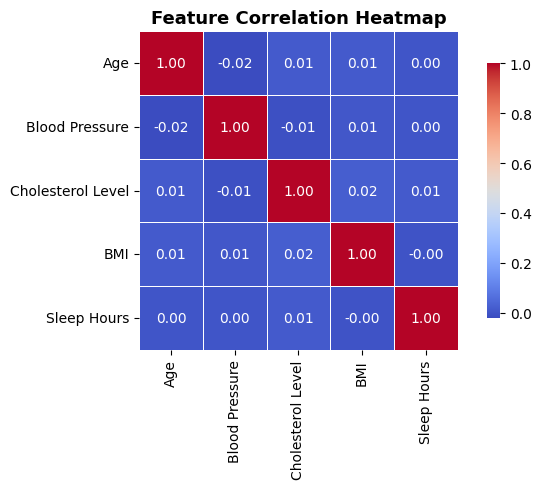

In [26]:
# Correlation heatmap
selected_features = ["Age", "Blood Pressure", "Cholesterol Level", "BMI", "Sleep Hours"]

plt.figure(figsize=(7, 5))
sns.heatmap(df[selected_features].corr(), annot=True, fmt='.2f',
            cmap='coolwarm', linewidths=0.5, square=True, cbar_kws={'shrink': 0.8})
plt.title('Feature Correlation Heatmap', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


## Step 4 — Preprocessing

In [27]:
# Separate numerical and categorical columns
num_cols = df.select_dtypes(include=['int64','float64']).columns
cat_cols = df.select_dtypes(include=['object']).columns

print("Numerical columns :", list(num_cols))
print("Categorical columns:", list(cat_cols))


Numerical columns : ['Age', 'Blood Pressure', 'Cholesterol Level', 'BMI', 'Sleep Hours', 'Triglyceride Level', 'Fasting Blood Sugar', 'CRP Level', 'Homocysteine Level']
Categorical columns: ['Gender', 'Exercise Habits', 'Smoking', 'Family Heart Disease', 'Diabetes', 'High Blood Pressure', 'Low HDL Cholesterol', 'High LDL Cholesterol', 'Alcohol Consumption', 'Stress Level', 'Sugar Consumption', 'Heart Disease Status']


In [28]:
# Handle missing values
df[cat_cols] = df[cat_cols].fillna(df[cat_cols].mode().iloc[0])   # mode for categorical
df[num_cols] = df[num_cols].fillna(df[num_cols].mean())            # mean for numerical

print("Missing values after imputation:", df.isnull().sum().sum())


Missing values after imputation: 0


In [29]:
# Feature selection
selected_features = ["Age", "Blood Pressure", "Cholesterol Level", "BMI", "Sleep Hours"]

X = df[selected_features]
y = df["Heart Disease Status"]

print("Features shape:", X.shape)
print("Target shape  :", y.shape)


Features shape: (10000, 5)
Target shape  : (10000,)


In [30]:
# Target encoding — False=0, True=1
le = LabelEncoder()
y = le.fit_transform(y)

print("Classes:", le.classes_)
print("0 →", le.classes_[0], "  |  1 →", le.classes_[1])

unique, counts = np.unique(y, return_counts=True)
for u, c in zip(unique, counts):
    print(f"  Class {u}: {c} samples ({c/len(y)*100:.1f}%)")


Classes: ['No' 'Yes']
0 → No   |  1 → Yes
  Class 0: 8000 samples (80.0%)
  Class 1: 2000 samples (20.0%)


In [31]:
# Train / Test split 
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training samples : {X_train.shape[0]}")
print(f"Test samples     : {X_test.shape[0]}")


Training samples : 8000
Test samples     : 2000


In [32]:
# Feature scaling — StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   
X_test_scaled  = scaler.transform(X_test)        

print("Scaling complete.")
print(f"Mean (train): {X_train_scaled.mean(axis=0).round(3)}")
print(f"Std  (train): {X_train_scaled.std(axis=0).round(3)}")


Scaling complete.
Mean (train): [ 0. -0. -0.  0. -0.]
Std  (train): [1. 1. 1. 1. 1.]


## Step 5 — Build the ANN Model (Keras Sequential API)

**Architecture:**
```
Input  →  5 neurons  (Age, Blood Pressure, Cholesterol, BMI, Sleep Hours)
          ↓
Hidden Layer 1  →  64 neurons  +  ReLU  +  BatchNorm  +  Dropout(0.3)
          ↓
Hidden Layer 2  →  32 neurons  +  ReLU  +  BatchNorm  +  Dropout(0.2)
          ↓
Hidden Layer 3  →  16 neurons  +  ReLU
          ↓
Output Layer    →  1 neuron   +  Sigmoid  →  probability (0 – 1)
```


In [33]:

tf.random.set_seed(42)
np.random.seed(42)

# Build the ANN using Keras Sequential API
model = keras.Sequential([

    # Input layer — explicitly define input shape
    layers.Input(shape=(5,)),

    # Hidden Layer 1
    layers.Dense(64, activation='relu'),          # 64 neurons, ReLU activation
    layers.BatchNormalization(),                   # normalize activations (stabilizes training)
    layers.Dropout(0.3),                          # randomly drop 30% neurons (prevents overfitting)

    # Hidden Layer 2
    layers.Dense(32, activation='relu'),           # 32 neurons
    layers.BatchNormalization(),
    layers.Dropout(0.2),                          # drop 20%

    # Hidden Layer 3
    layers.Dense(16, activation='relu'),           # 16 neurons

    # Output Layer
    layers.Dense(1, activation='sigmoid')          # 1 neuron, sigmoid → probability 0–1
])

model.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 64)             │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,393 (13.25 KB)

 Trainable params: 3,201 (12.50 KB)

 Non-trainable params: 192 (768.00 B)

## Step 6 — Compile the Model

In [34]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),   # Adam optimizer
    loss='binary_crossentropy',                              # BCE loss for binary classification
    metrics=['accuracy']                                    
)

print(" Model compiled.")
print("Optimizer : Adam (lr=0.001)")
print("Loss      : Binary Cross-Entropy")
print("Metrics   : Accuracy")


 Model compiled.
Optimizer : Adam (lr=0.001)
Loss      : Binary Cross-Entropy
Metrics   : Accuracy


## Step 7 — Set Up Training Callbacks

In [35]:
# EarlyStopping — stops training if val_loss stops improving (avoids overfitting)
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=20,            
    restore_best_weights=True,   # restore weights from best epoch
    verbose=1
)

# ReduceLROnPlateau — cuts learning rate when val_loss plateaus
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,              # multiply lr by 0.5
    patience=10,            
    min_lr=1e-6,
    verbose=1
)

callbacks = [early_stop, reduce_lr]
print("Callbacks ready: EarlyStopping + ReduceLROnPlateau")


Callbacks ready: EarlyStopping + ReduceLROnPlateau


## Step 8 — Train the Model

In [36]:
history = model.fit(
    X_train_scaled, y_train,
    epochs=150,
    batch_size=32,
    validation_data=(X_test_scaled, y_test),
    callbacks=callbacks,
    verbose=1
)

print("\n Training complete!")
print(f"Stopped at epoch: {len(history.history['loss'])}")


Epoch 1/150
250/250 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7695 - loss: 0.5501 - val_accuracy: 0.8000 - val_loss: 0.5203 - learning_rate: 0.0010
Epoch 2/150
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7985 - loss: 0.5178 - val_accuracy: 0.8000 - val_loss: 0.5130 - learning_rate: 0.0010
Epoch 3/150
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7996 - loss: 0.5124 - val_accuracy: 0.8000 - val_loss: 0.5096 - learning_rate: 0.0010
Epoch 4/150
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7999 - loss: 0.5065 - val_accuracy: 0.8000 - val_loss: 0.5109 - learning_rate: 0.0010
Epoch 5/150
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7999 - loss: 0.5079 - val_accuracy: 0.8000 - val_loss: 0.5073 - learning_rate: 0.0010
Epoch 6/150
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8000 - loss: 0.5047 - val_accuracy: 0.8000 - val_loss: 0.5062 - learning_rate: 0.0010
Epoch 7/150
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8000 - loss: 0.

## Step 9 — Plot Training Curves

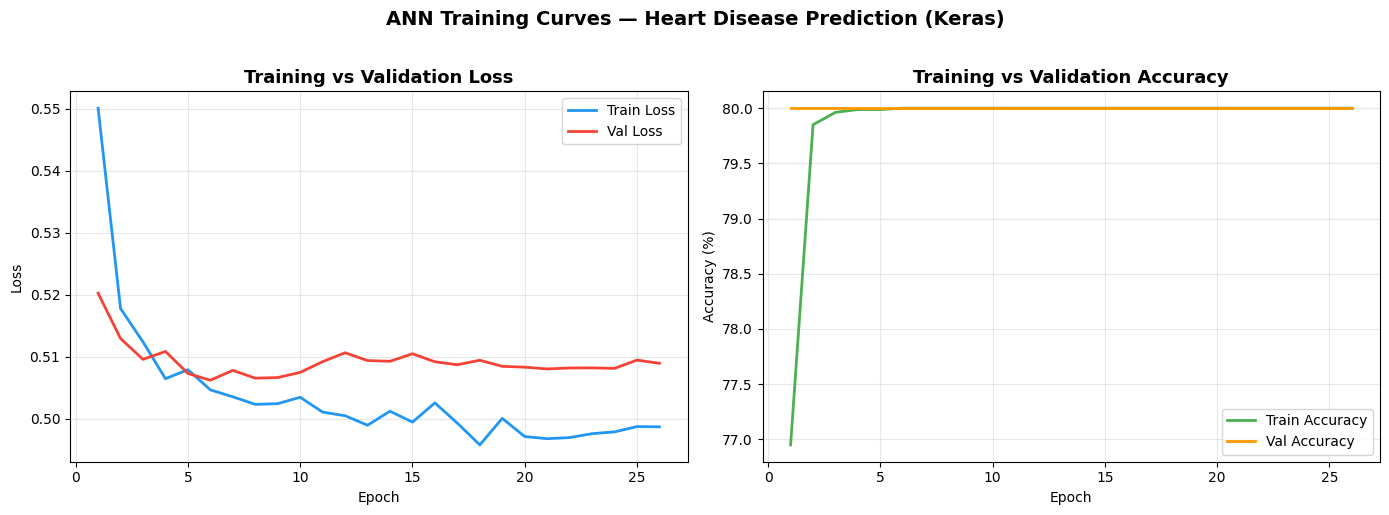

Best Val Loss    : 0.5062
Best Val Accuracy: 80.00%


In [37]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

epochs_ran = range(1, len(history.history['loss']) + 1)

# Loss curve
axes[0].plot(epochs_ran, history.history['loss'],     label='Train Loss', color='#2196F3', linewidth=2)
axes[0].plot(epochs_ran, history.history['val_loss'], label='Val Loss',   color='#F44336', linewidth=2)
axes[0].set_title('Training vs Validation Loss', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

# Accuracy curve
axes[1].plot(epochs_ran, [v*100 for v in history.history['accuracy']],     label='Train Accuracy', color='#4CAF50', linewidth=2)
axes[1].plot(epochs_ran, [v*100 for v in history.history['val_accuracy']], label='Val Accuracy',   color='#FF9800', linewidth=2)
axes[1].set_title('Training vs Validation Accuracy', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy (%)')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.suptitle('ANN Training Curves — Heart Disease Prediction (Keras)', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f"Best Val Loss    : {min(history.history['val_loss']):.4f}")
print(f"Best Val Accuracy: {max(history.history['val_accuracy'])*100:.2f}%")


## Step 10 — Model Evaluation

In [38]:
# Get predictions
y_pred_prob = model.predict(X_test_scaled).flatten()   # probabilities
y_pred      = (y_pred_prob >= 0.5).astype(int)         # binary labels

print("=== ANN Model Evaluation (TensorFlow/Keras) ===\n")
print(f"Accuracy: {accuracy_score(y_test, y_pred)*100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['No Disease','Heart Disease']))


63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
=== ANN Model Evaluation (TensorFlow/Keras) ===

Accuracy: 80.00%

Classification Report:
               precision    recall  f1-score   support

   No Disease       0.80      1.00      0.89      1600
Heart Disease       0.00      0.00      0.00       400

     accuracy                           0.80      2000
    macro avg       0.40      0.50      0.44      2000
 weighted avg       0.64      0.80      0.71      2000



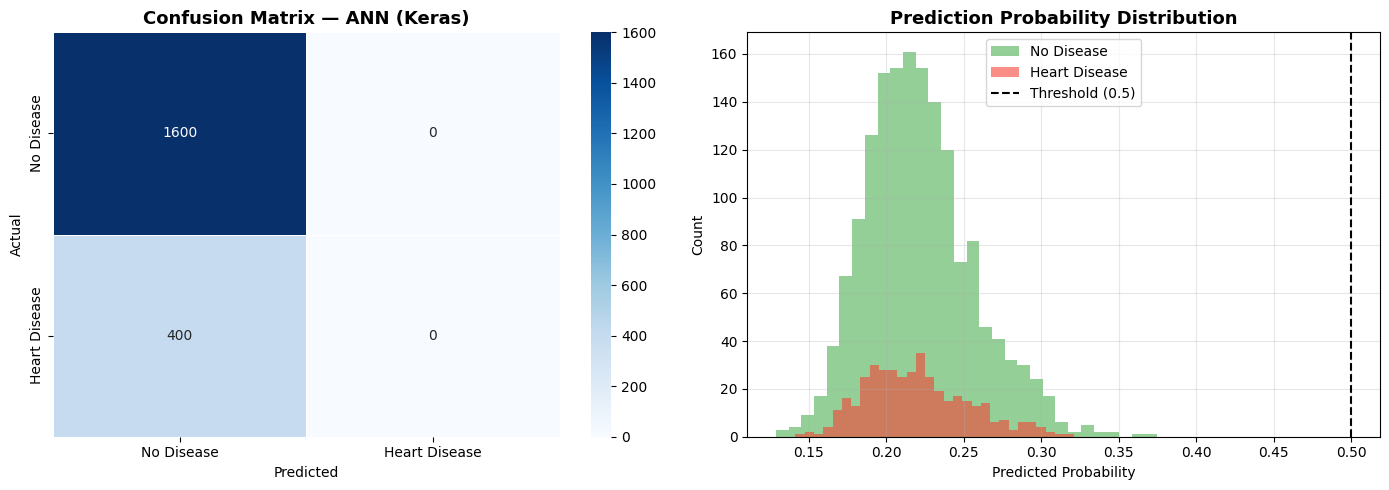

In [39]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Disease','Heart Disease'],
            yticklabels=['No Disease','Heart Disease'],
            ax=axes[0], linewidths=0.5)
axes[0].set_title('Confusion Matrix — ANN (Keras)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('Actual')

# Probability distribution
axes[1].hist(y_pred_prob[y_test == 0], bins=30, alpha=0.6, color='#4CAF50', label='No Disease')
axes[1].hist(y_pred_prob[y_test == 1], bins=30, alpha=0.6, color='#F44336', label='Heart Disease')
axes[1].axvline(x=0.5, color='black', linestyle='--', linewidth=1.5, label='Threshold (0.5)')
axes[1].set_title('Prediction Probability Distribution', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Predicted Probability'); axes[1].set_ylabel('Count')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## Step 11 — Save the Model & Scaler

In [43]:
# Save Keras model in native .keras format
model.save("heart_ann_model.h5")
print("Saved as H5!")

# Save scaler
pickle.dump(scaler, open("scaler.pkl", "wb"))

print(" Scaler saved : scaler.pkl")

# Verify by loading back
test_load = keras.models.load_model("heart_ann_model.keras")
print("\nModel loaded back successfully — ready for deployment!")


Saved as H5!
 Scaler saved : scaler.pkl

Model loaded back successfully — ready for deployment!


## Step 12 — Gradio Interface

In [41]:
import gradio as gr

# Load saved model and scaler
loaded_model  = keras.models.load_model("heart_ann_model.keras")
loaded_scaler = pickle.load(open("scaler.pkl", "rb"))

# Prediction function
def predict_heart_disease(age, blood_pressure, cholesterol, bmi, sleep_hours):
    # Step 1: Arrange input
    input_data = np.array([[age, blood_pressure, cholesterol, bmi, sleep_hours]])

    # Step 2: Scale using the same scaler from training
    input_scaled = loaded_scaler.transform(input_data)

    # Step 3: Predict probability
    probability = loaded_model.predict(input_scaled, verbose=0)[0][0]

    # Step 4: Return result
    if probability >= 0.5:
        result = " Heart Disease Detected"
        detail = (f"Risk Probability : {probability*100:.1f}%\n"
                  f"Status           : HIGH RISK\n"
                  f"Recommendation   : Please consult a cardiologist immediately.")
    else:
        result = " No Heart Disease Detected"
        detail = (f"Risk Probability : {probability*100:.1f}%\n"
                  f"Status           : LOW RISK\n"
                  f"Recommendation   : Maintain a healthy lifestyle and regular checkups.")

    return result, detail

# Build interface with gr.Blocks
with gr.Blocks(title="Heart Disease Prediction") as demo:

    gr.Markdown("""
    # ❤️ Heart Disease Prediction App
    ### Deep Learning — Artificial Neural Network (ANN) | TensorFlow / Keras
    Adjust the sliders and click **Predict** to check heart disease risk.
    """)

    with gr.Row():
        with gr.Column(scale=1):
            age            = gr.Slider(20,  90,  value=45,  step=1,   label="Age (years)")
            blood_pressure = gr.Slider(60,  200, value=120, step=1,   label="Blood Pressure (mmHg)")
            cholesterol    = gr.Slider(100, 400, value=200, step=1,   label="Cholesterol Level (mg/dL)")
            bmi            = gr.Slider(10,  50,  value=25,  step=0.1, label="BMI")
            sleep_hours    = gr.Slider(3,   12,  value=7,   step=0.5, label="Sleep Hours (per night)")
            predict_btn    = gr.Button("🔍 Predict", variant="primary")

        with gr.Column(scale=1):
            output_label  = gr.Textbox(label="Prediction Result", lines=1)
            output_detail = gr.Textbox(label="Details & Recommendation", lines=4)

    predict_btn.click(
        fn=predict_heart_disease,
        inputs=[age, blood_pressure, cholesterol, bmi, sleep_hours],
        outputs=[output_label, output_detail]
    )

    
demo.launch(share=True)


* Running on local URL:  http://127.0.0.1:7860

Could not create share link. Please check your internet connection or our status page: https://status.gradio.app.


In [45]:
model.save(r"C:\Users\LENOVO\OneDrive\Desktop\DL PROJECT\heart_ann_model.h5")
print("Saved to DL PROJECT folder!")

Saved to DL PROJECT folder!
